# MiniGrid-Fetch-8x8-N3-v0 — Model Comparison with Imitation Learning

Trains **4 variants** back-to-back, then overlays training curves, prints an evaluation table, and saves episode grids + GIFs for each variant.

| Variant | Fusion | memo + text | Reward |
|---------|-------|----------|--------|
| `baseline`  | Non | OFF  | sparse |
| `memo_text`  | Concat | ON | sparse |
| `film_dense`   | FiLM          | ON  | dense  |
| `film_sparse`  | FiLM          | ON  | sparse |

## 1 · Imports and configuration

In [ ]:
import os, sys, csv, random, time
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch_ac
import yaml
import matplotlib.pyplot as plt

# Add the project root to sys.path so local utility modules are importable
ROOT = Path(os.getcwd())
sys.path.insert(0, str(ROOT))

from utils.format import get_obss_preprocessor
from utils.env import make_env
from utils.plotting import (format_update_log, plot_training_curves,
                                   record_episode, show_animations,
                                   save_gifs, show_episode_grid)
from utils.model_baseline import ACModel as BaselineACModel
from utils.model_film import ACModel as FilmACModel

# Load hyperparameters and environment settings from the shared YAML config file
with open(ROOT / 'config.YAML') as f:
    CFG = yaml.safe_load(f)

SEED   = CFG['seed']
env_id = "MiniGrid-Fetch-8x8-N3-v0"
ppo    = CFG['ppo']
rew    = CFG['reward']

# Fix all random-number generators for reproducibility across runs
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Select GPU if available; otherwise fall back to CPU
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Device : {DEVICE}')
print(f'Env    : {env_id}')
print(f'Seed   : {SEED}')
print(f'Frames : {ppo["frames_max"]:,}')

Device : cuda
Env    : MiniGrid-Fetch-8x8-N3-v0
Seed   : 1
Frames : 5,000,000


## 2 · Shared vocab, preprocessing, and variant definitions

In [ ]:
# ── Shared preprocessing + action space ─────────────────────────────────────────
# Instantiate a temporary environment solely to derive the observation space
# and build the shared observation preprocessor used by all variants.
_tmp = make_env(env_id, dense_reward=False)
obs_space, preprocess_fn = get_obss_preprocessor(_tmp.observation_space)
action_space = _tmp.action_space
_tmp.close()

print(f"Text capacity : {obs_space['text']}")
print(f'Actions    : {action_space.n}')
print()

# ── Variant definitions ───────────────────────────────────────────────────────
# Each entry specifies a model architecture and reward configuration to compare.
# Fields:
#   name        – unique identifier used for directory naming and dict keys
#   label       – human-readable name shown in plots and tables
#   model_class – ACModel class to instantiate (BaselineACModel or FilmACModel)
#   use_memory  – whether to include the LSTM memory module
#   use_text    – whether to include the GRU text encoder
#   dense       – whether to use dense (shaped) reward instead of sparse reward
#   color       – matplotlib colour used consistently across all plots
VARIANTS = [
    {
        'name':        'baseline_nm',
        'label':       'Baseline',
        'model_class': BaselineACModel,
        'use_memory':  False,
        'use_text':    False,
        'dense':       False,
        'color':       'darkorange',
    },

    {
        'name':        'memo_text',
        'label':       'Memory + text=ON',
        'model_class': BaselineACModel,
        'use_memory':  True,
        'use_text':    True,
        'dense':       False,
        'color':       'steelblue',
    },

    {
        'name':        'film_sparse',
        'label':       'FiLM  sparse reward',
        'model_class': FilmACModel,
        'use_memory':  True,
        'use_text':    True,
        'dense':       False,
        'color':       'crimson',
    },

    {
        'name':        'film_dense',
        'label':       'FiLM  dense reward',
        'model_class': FilmACModel,
        'use_memory':  True,
        'use_text':    True,
        'dense':       True,
        'color':       'seagreen',
    },
]

# Preview parameter counts and model structure
print(f'{"Variant":<22}  {"Params":>10}')
print('-' * 35)
for v in VARIANTS:
    m = v['model_class'](
        obs_space, action_space,
        use_memory=v['use_memory'], use_text=v['use_text'],
    )
    n = sum(p.numel() for p in m.parameters())
    print(f"{v['label']:<22}  {n:>10,}")
    print(f"\nModel structure:\n{m}\n")
    del m

Text capacity : 100
Actions    : 7

Variant                     Params
-----------------------------------
Baseline                    19,384

Model structure:
ACModel(
  (image_conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(2, 2), stride=(1, 1))
    (4): ReLU()
    (5): Conv2d(32, 64, kernel_size=(2, 2), stride=(1, 1))
    (6): ReLU()
  )
  (actor): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=7, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Memory + text=ON           134,456

Model structure:
ACModel(
  (image_conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(2, 2), stride=(1, 1))
    (

## 3 · Training function

In [ ]:
# Column names written to the CSV log for each PPO update
CSV_FIELDS = ['update', 'global_step', 'mean_ep_return', 'mean_ep_len',
              'entropy', 'policy_loss', 'value_loss', 'grad_norm']


def train_variant(variant):
    """Train one variant from scratch. Returns (run_dir, csv_path, model)."""
    name      = variant['name']
    use_dense = variant['dense']

    # ── directories ───────────────────────────────────────────────────────────
    # Create a timestamped run directory to avoid overwriting previous results
    ts       = datetime.now().strftime('%d-%m-%y-%H-%M-%S')
    run_dir  = f"runs/{env_id}_{name}_seed{SEED}_{ts}"
    ckpt_dir = os.path.join(run_dir, 'checkpoints')
    csv_path = os.path.join(run_dir, 'training_log.csv')
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*72}")
    print(f"  {variant['label']}")
    print(f"  dir : {run_dir}")
    print(f"{'='*72}")

    # ── model ─────────────────────────────────────────────────────────────────
    # Instantiate the model and move it to the selected compute device
    model = variant['model_class'](
        obs_space, action_space,
        use_memory=variant['use_memory'],
        use_text=variant['use_text'],
    ).to(DEVICE)

    # ── PPO algo ──────────────────────────────────────────────────────────────
    # Dense-reward variants include shaped reward kwargs; sparse variants use
    # the default environment reward without any additional shaping.
    reward_kwargs = dict(
        step_penalty           = rew['step_penalty'],
        first_sight_bonus      = rew['first_sight_bonus'],
        approach_scale         = rew['approach_scale'],
        success_reward         = rew['success_reward'],
        useless_action_penalty = rew['useless_action_penalty'],
    ) if use_dense else {}

    # Each parallel environment is seeded independently to maximise diversity
    # in the training data while remaining fully reproducible.
    algo = torch_ac.PPOAlgo(
        [
            make_env(env_id, dense_reward=use_dense, seed=SEED + 10000 * i, **reward_kwargs)
            for i in range(CFG['env']['n_envs'])
        ],
        model,
        DEVICE,
        ppo['rollout_steps'],
        ppo['gamma'],
        ppo['lr'],
        ppo['gae_lambda'],
        ppo['ent_coef'],
        ppo['value_coef'],
        ppo['max_grad_norm'],
        ppo['recurrence'],
        ppo.get('optim_eps', 1e-8),
        ppo['clip_eps'],
        ppo['train_epochs'],
        ppo['batch_size'],
        preprocess_fn,
    )

    # ── CSV header ────────────────────────────────────────────────────────────
    with open(csv_path, 'w', newline='') as f:
        csv.DictWriter(f, CSV_FIELDS).writeheader()

    # ── training loop ─────────────────────────────────────────────────────────
    num_frames = 0
    update_idx = 0
    save_every = CFG['logging']['save_interval']
    t_last     = time.time()

    while num_frames < ppo['frames_max']:
        # Collect a rollout across all parallel environments
        exps, logs = algo.collect_experiences()
        # Run PPO gradient updates on the collected rollout
        upd_logs   = algo.update_parameters(exps)
        num_frames += logs['num_frames']
        update_idx += 1

        # Build the CSV row; episode-level stats may be absent when no episode
        # completed during this rollout, so an empty string is stored instead.
        row = dict(
            update         = update_idx,
            global_step    = num_frames,
            mean_ep_return = (np.mean(logs['return_per_episode'])
                              if logs['return_per_episode'] else ''),
            mean_ep_len    = (np.mean(logs['num_frames_per_episode'])
                              if logs['num_frames_per_episode'] else ''),
            entropy     = upd_logs['entropy'],
            policy_loss = upd_logs['policy_loss'],
            value_loss  = upd_logs['value_loss'],
            grad_norm   = upd_logs['grad_norm'],
        )
        with open(csv_path, 'a', newline='') as f:
            csv.DictWriter(f, CSV_FIELDS).writerow(row)

        # Periodically checkpoint the model weights
        if num_frames % save_every < logs['num_frames']:
            ckpt = os.path.join(ckpt_dir, f'model_{num_frames}.pt')
            torch.save(model.state_dict(), ckpt)

        t_now    = time.time()
        duration = t_now - t_last
        fps      = logs['num_frames'] / max(duration, 1e-6)
        t_last   = t_now
        print(format_update_log(update_idx, num_frames, fps, duration, logs, upd_logs))

    # Save the final model weights after training is complete
    ckpt_final = os.path.join(ckpt_dir, 'model_final.pt')
    torch.save(model.state_dict(), ckpt_final)
    print(f"  Saved -> {ckpt_final}")

    return run_dir, csv_path, model

## 4 · Train all variants

In [ ]:
# run_results maps each variant name to its run directory, CSV log path,
# trained model, and variant config dict for downstream evaluation and plotting.
run_results = {}   # name -> {run_dir, csv_path, model, variant}

for v in VARIANTS:
    run_dir, csv_path, trained_model = train_variant(v)
    run_results[v['name']] = {
        'run_dir':  run_dir,
        'csv_path': csv_path,
        'model':    trained_model,
        'variant':  v,
    }

print('\n\nAll variants trained.')
for name, info in run_results.items():
    print(f"  {name:<20}  {info['run_dir']}")


  Baseline
  dir : runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34
U 1 | F 004096 | FPS 3323 | D 1 | rR:μσmM 0.37 0.41 0.00 1.00 | F:μσmM 82.04 63.50 1.00 221.00 | H 1.912 | V -0.197 | pL -0.094 | vL 0.020 | ∇ 0.117
U 2 | F 008192 | FPS 3543 | D 1 | rR:μσmM 0.24 0.34 0.00 0.98 | F:μσmM 117.41 101.11 1.00 320.00 | H 1.907 | V -0.108 | pL -0.098 | vL 0.020 | ∇ 0.096
U 3 | F 012288 | FPS 3599 | D 1 | rR:μσmM 0.18 0.33 0.00 0.96 | F:μσmM 91.39 80.49 4.00 320.00 | H 1.910 | V -0.047 | pL -0.056 | vL 0.013 | ∇ 0.069
U 4 | F 016384 | FPS 3693 | D 1 | rR:μσmM 0.26 0.39 0.00 0.98 | F:μσmM 90.80 75.45 8.00 320.00 | H 1.907 | V -0.013 | pL -0.046 | vL 0.014 | ∇ 0.061
U 5 | F 020480 | FPS 3778 | D 1 | rR:μσmM 0.39 0.43 0.00 0.99 | F:μσmM 74.15 75.73 1.00 320.00 | H 1.858 | V 0.061 | pL -0.093 | vL 0.035 | ∇ 0.137
U 6 | F 024576 | FPS 3694 | D 1 | rR:μσmM 0.41 0.44 0.00 1.00 | F:μσmM 45.41 43.34 1.00 261.00 | H 1.843 | V 0.134 | pL -0.088 | vL 0.036 | ∇ 0.128
U 7 | F 028672 | FPS

## 5 · Comparison: training curves

Saved -> runs/comparison_curves.png


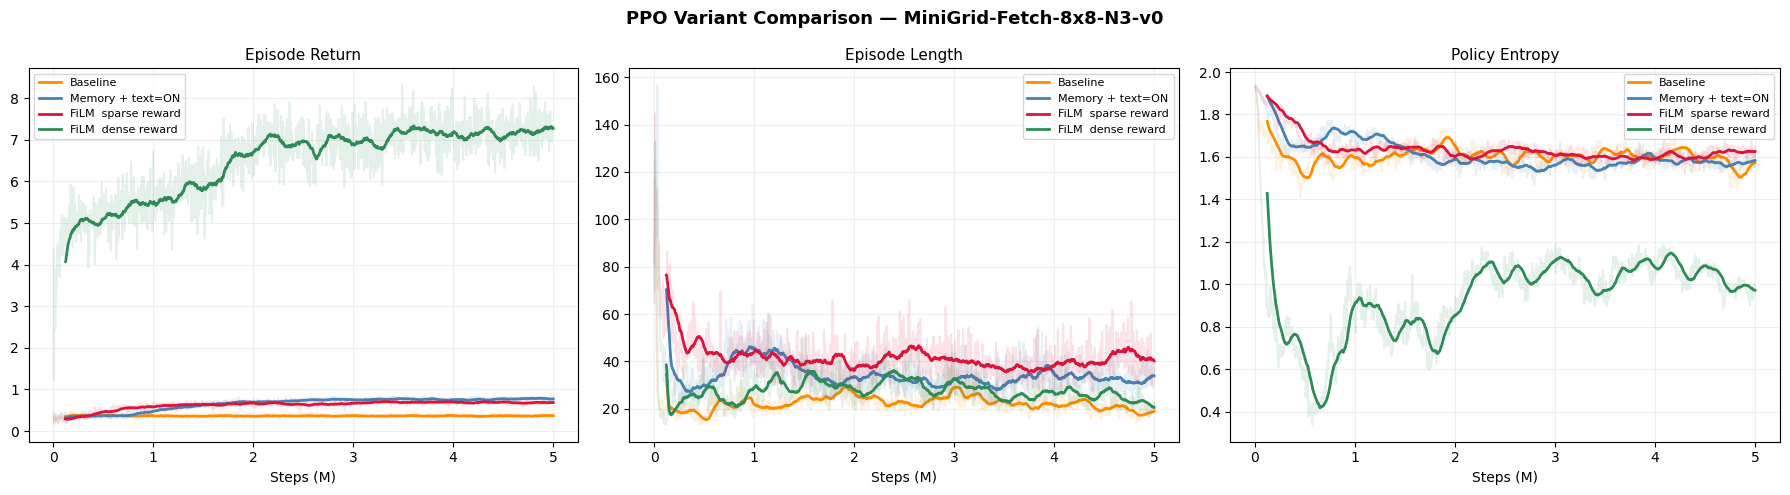

Saved -> runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/training_curves.png


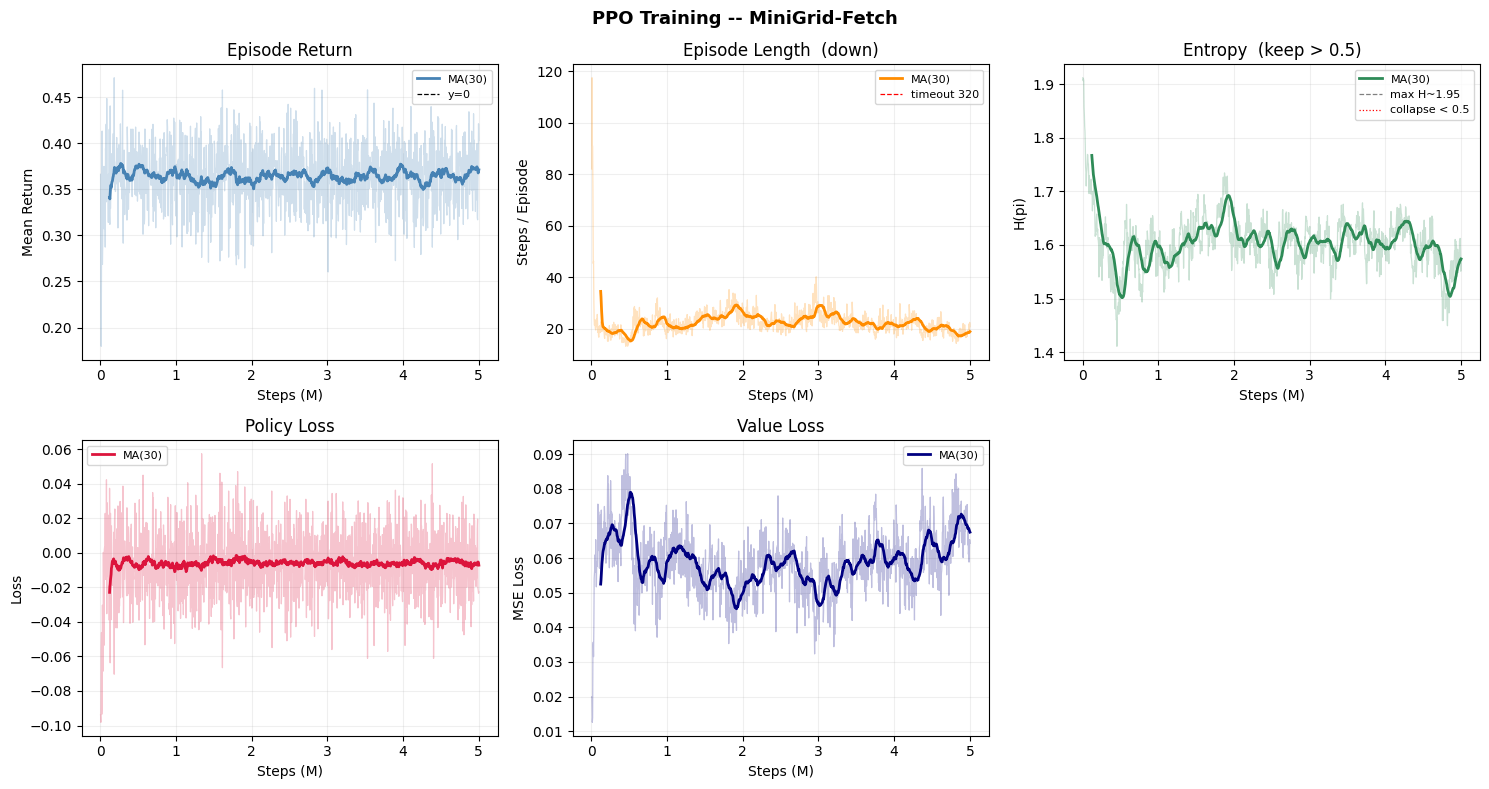


Final stats (last 50 updates):
  Return    : 0.3724
  Length    : 18.2482
  Entropy   : 1.5502
  PG Loss   : -0.0078
Saved -> runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/training_curves.png


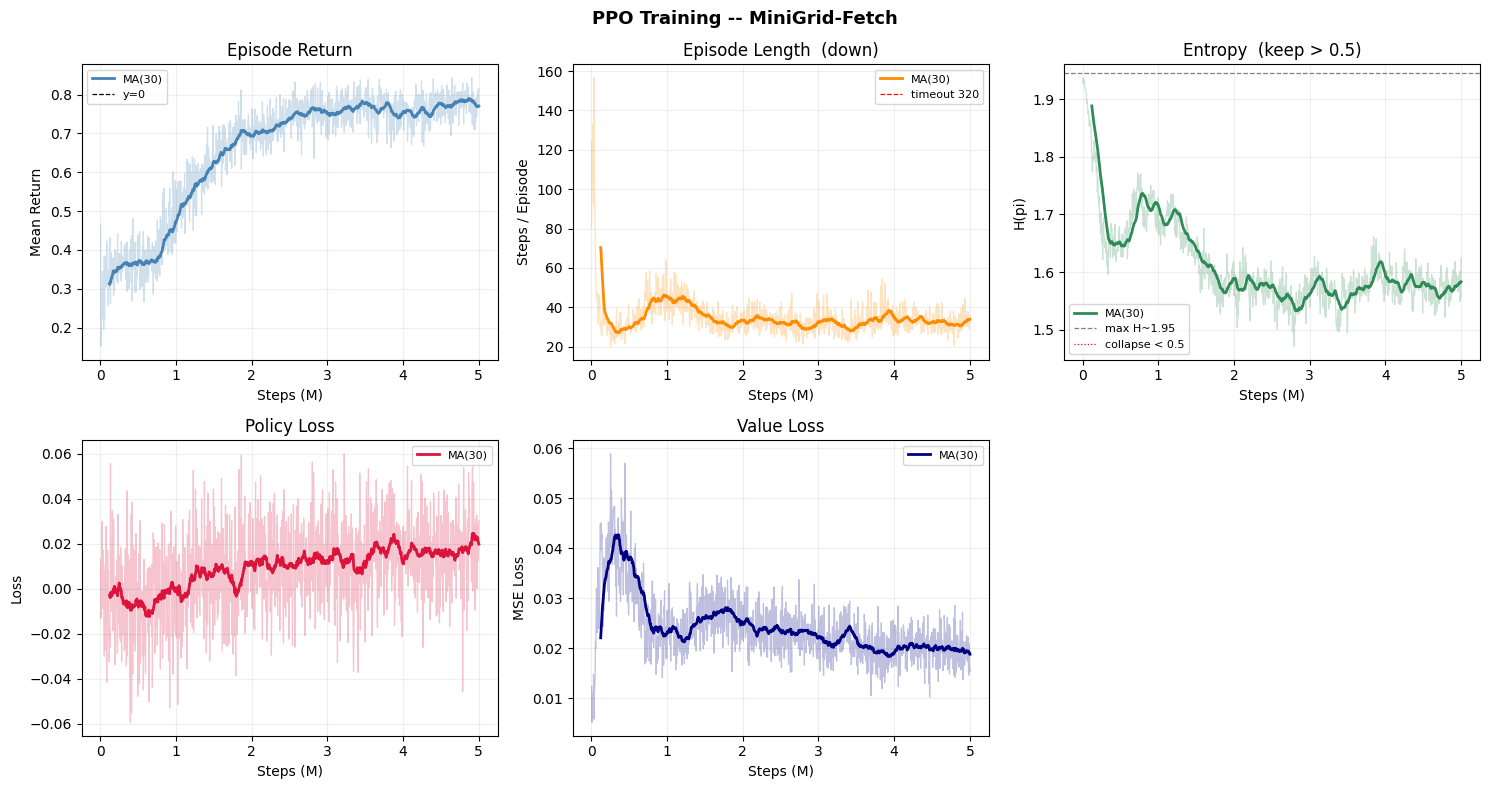


Final stats (last 50 updates):
  Return    : 0.7781
  Length    : 32.8472
  Entropy   : 1.5774
  PG Loss   : 0.0213
Saved -> runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/training_curves.png


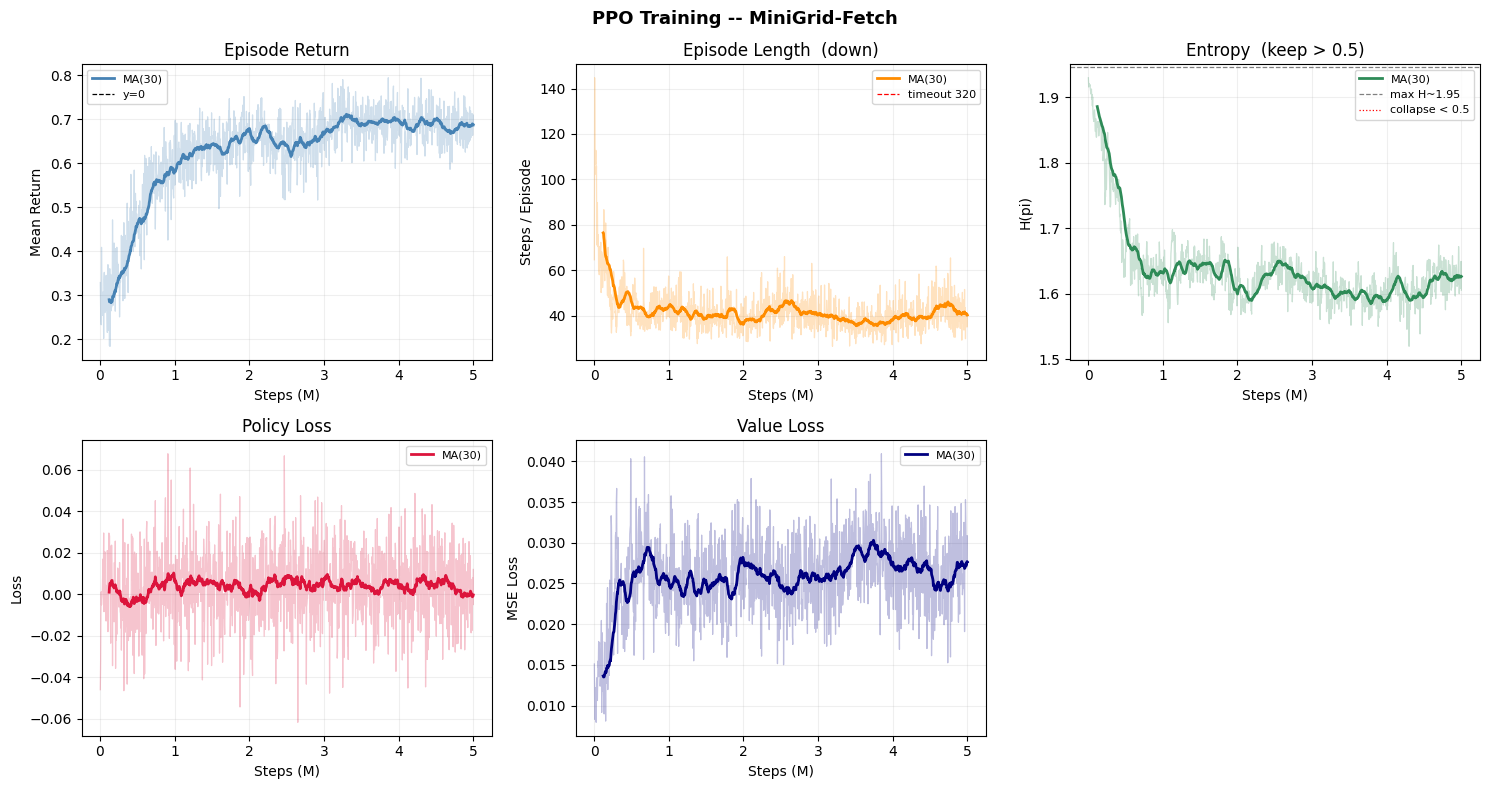


Final stats (last 50 updates):
  Return    : 0.6868
  Length    : 40.1527
  Entropy   : 1.6242
  PG Loss   : 0.0002
Saved -> runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/training_curves.png


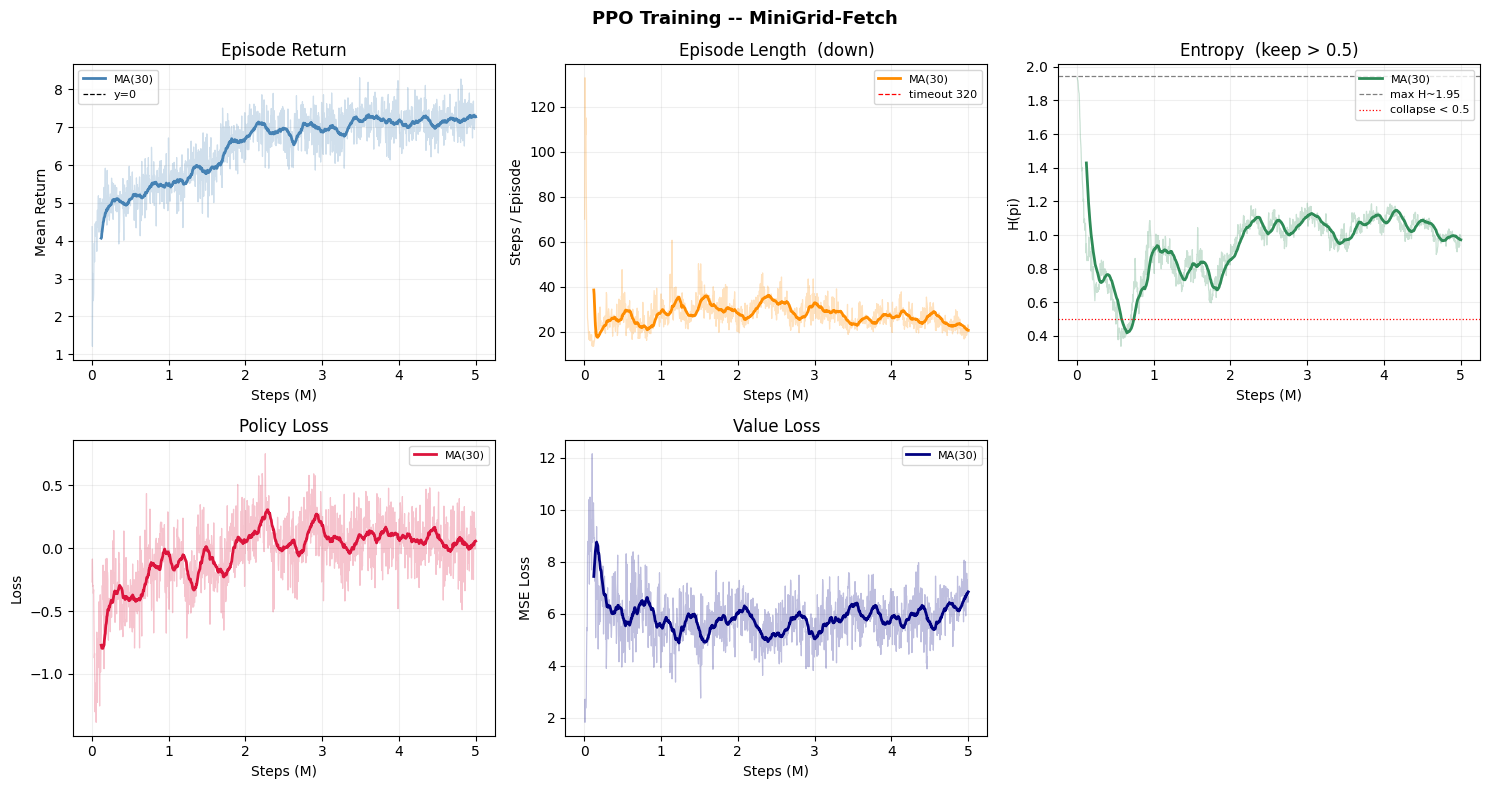


Final stats (last 50 updates):
  Return    : 7.2758
  Length    : 21.8682
  Entropy   : 0.9813
  PG Loss   : 0.0338


In [ ]:
def _col(rows, key):
    """Extract a numeric column from a list of CSV row dicts, skipping blanks."""
    return np.array([float(r[key]) for r in rows if r.get(key) not in (None, '')])

def _smooth(arr, w=30):
    """Apply a uniform moving-average of width w; returns arr unchanged if too short."""
    return np.convolve(arr, np.ones(w) / w, mode='valid') if len(arr) >= w else arr


def plot_comparison(run_results, smooth_window=30, save_path=None):
    W   = smooth_window
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'PPO Variant Comparison — {env_id}', fontsize=13, fontweight='bold')

    # Each panel plots a different training metric against environment steps
    panels = [
        ('mean_ep_return', 'Episode Return',  axes[0]),
        ('mean_ep_len',    'Episode Length',  axes[1]),
        ('entropy',        'Policy Entropy',  axes[2]),
    ]

    for name, info in run_results.items():
        v = info['variant']
        with open(info['csv_path'], newline='') as f:
            rows = list(csv.DictReader(f))
        # Convert frame count to millions for a readable x-axis
        steps = _col(rows, 'global_step') / 1e6

        for key, _, ax in panels:
            y = _col(rows, key)
            x = steps[:len(y)]
            # Plot raw (low-opacity) and smoothed (solid) curves for each variant
            ax.plot(x, y, alpha=0.12, color=v['color'])
            if len(y) >= W:
                ax.plot(x[W-1:], _smooth(y, W), color=v['color'],
                        linewidth=2, label=v['label'])

    for key, title, ax in panels:
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Steps (M)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved -> {save_path}')
    plt.show()


plot_comparison(
    run_results,
    save_path=os.path.join('runs', 'comparison_curves.png'),
)

# Also save per-variant curves
for name, info in run_results.items():
    plot_training_curves(info['csv_path'], save_dir=info['run_dir'])

## 6 · Evaluation table

In [ ]:
N_EVAL = CFG['eval']['n_episodes']

print(f"Evaluating {N_EVAL} episodes per variant (sparse reward, stochastic policy)...\n")
print(f"{'Variant':<26}  {'Return μ':>9}  {'Return σ':>9}  {'Length μ':>9}  {'Success':>8}")
print('-' * 70)

for name, info in run_results.items():
    model   = info['model']
    variant = info['variant']
    # Switch to eval mode to disable dropout / batch-norm training behaviour
    model.eval()

    ep_rets, ep_lens, successes = [], [], []
    for seed in range(N_EVAL):
        # record_episode runs one episode and returns
        # (frames, actions, success_flag, mission_string, total_return)
        _, acts, success, _, ret = record_episode(
            model, preprocess_fn, env_id, DEVICE,
            seed=seed, dense_reward=False,
        )
        ep_rets.append(ret)
        ep_lens.append(len(acts))
        successes.append(int(success))

    # Cache results so they can be reused by the visualisation cells below
    info['ep_rets']   = ep_rets
    info['ep_lens']   = ep_lens
    info['successes'] = successes

    print(f"{variant['label']:<26}  "
          f"{np.mean(ep_rets):>9.4f}  "
          f"{np.std(ep_rets):>9.4f}  "
          f"{np.mean(ep_lens):>9.1f}  "
          f"{np.mean(successes):>8.1%}")

Evaluating 50 episodes per variant (sparse reward, stochastic policy)...

Variant                      Return μ   Return σ   Length μ   Success
----------------------------------------------------------------------
Baseline                       0.3652     0.4669       15.4     38.0%
Memory + text=ON               0.7334     0.3742       32.7     80.0%
FiLM  sparse reward            0.6504     0.3993       49.6     74.0%
FiLM  dense reward             0.4640     0.4565       28.4     52.0%


## 7 · Visualise — episode grids and GIFs

Recording 6 episodes per variant...

  [baseline_nm] seed=  0  'go get a yellow ball'                 3 steps  [SUCCESS]
  [baseline_nm] seed=  7  'you must fetch a green ball'          3 steps  [SUCCESS]
  [baseline_nm] seed= 42  'get a yellow key'                    13 steps  [failed]
  [baseline_nm] seed= 77  'you must fetch a red key'             5 steps  [failed]
  [baseline_nm] seed=123  'get a yellow key'                     5 steps  [failed]
  [baseline_nm] seed=256  'fetch a yellow ball'                  7 steps  [failed]
  success 2/6

Saved -> runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/episode_grid.png


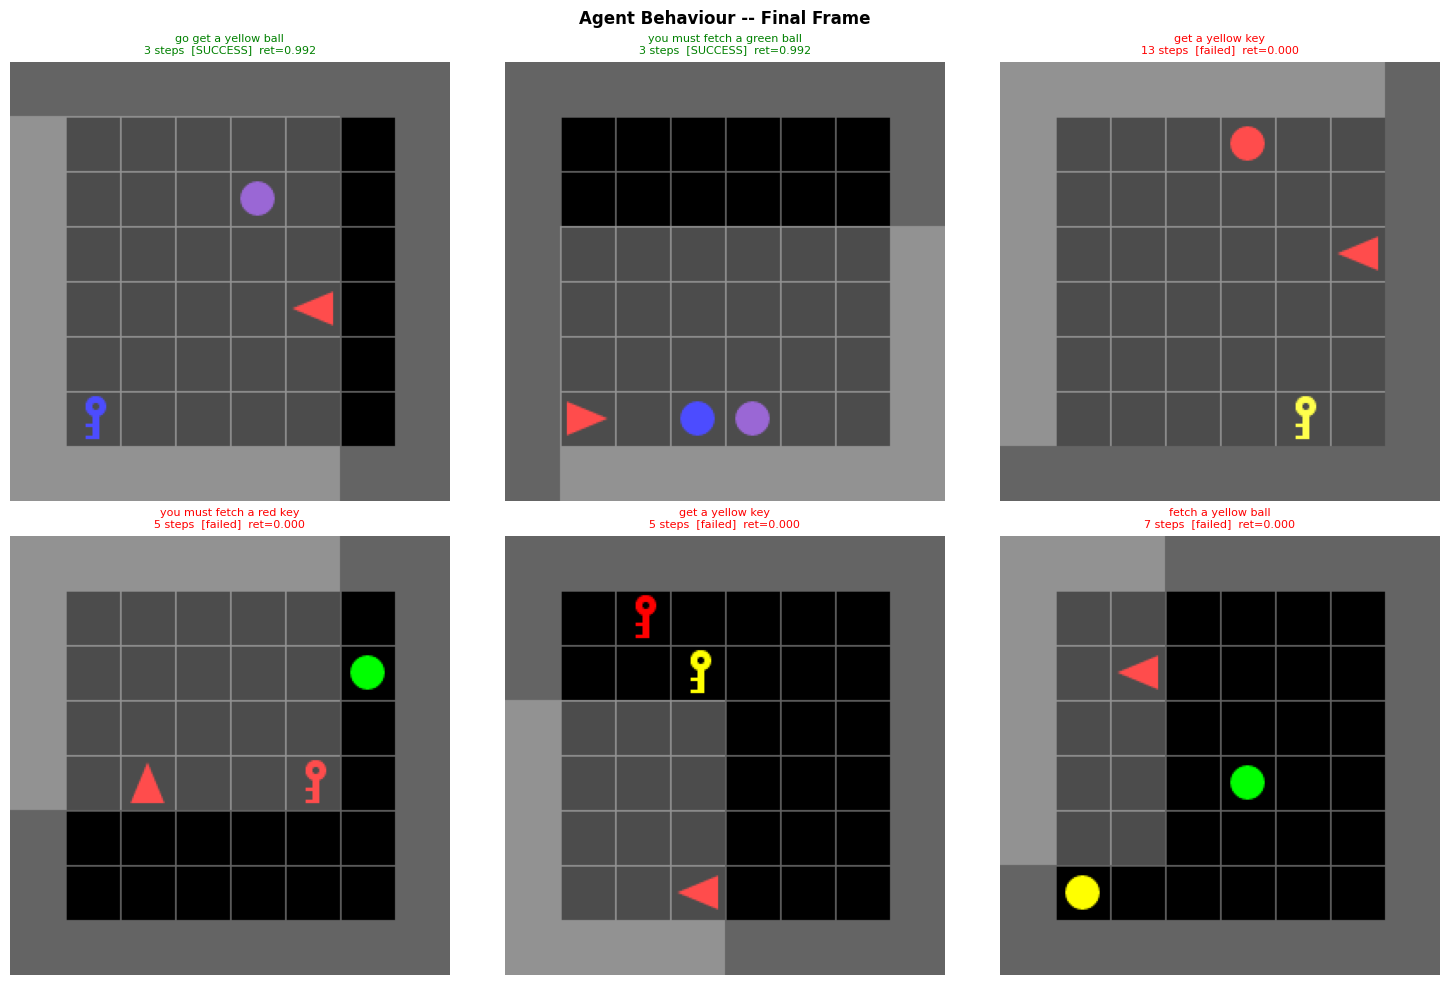

  Saved runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/gifs/ep01_ok.gif  (4 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/gifs/ep02_ok.gif  (4 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/gifs/ep03_fail.gif  (14 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/gifs/ep04_fail.gif  (6 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/gifs/ep05_fail.gif  (6 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_baseline_nm_seed1_25-02-26-09-58-34/gifs/ep06_fail.gif  (8 frames)
  [memo_text] seed=  0  'go get a yellow ball'                 1 steps  [SUCCESS]
  [memo_text] seed=  7  'you must fetch a green ball'          1 steps  [SUCCESS]
  [memo_text] seed= 42  'get a yellow key'                    12 steps  [SUCCESS]
  [memo_text] seed= 77  'you must fetch a red key'            42 steps  [SUCCESS]
  [memo_text] seed=123  'get a yellow key'   

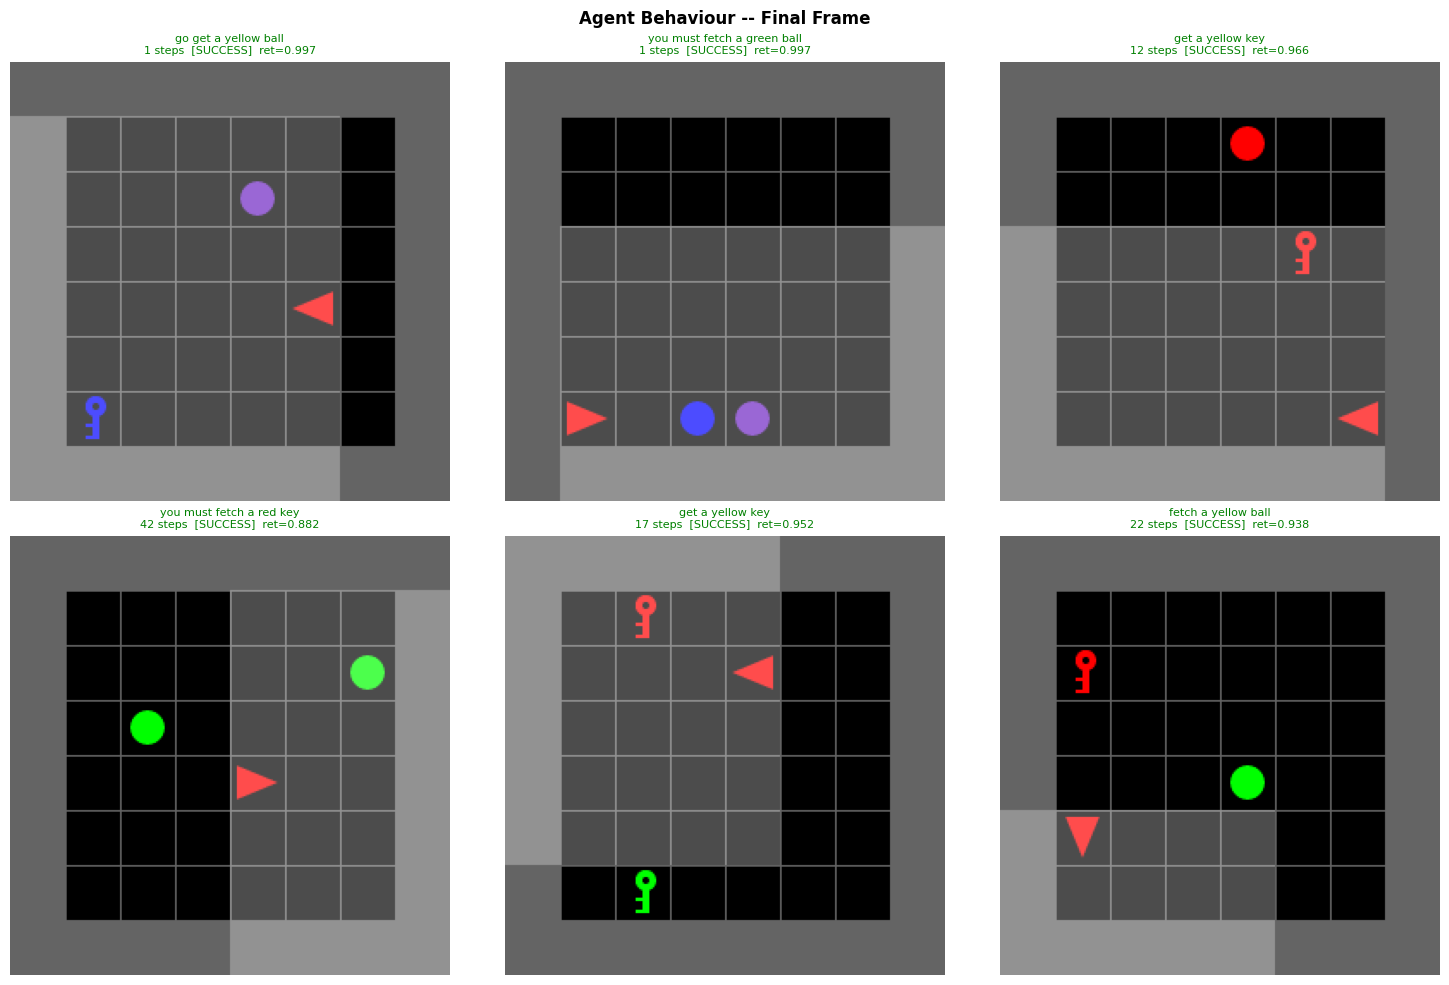

  Saved runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/gifs/ep01_ok.gif  (2 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/gifs/ep02_ok.gif  (2 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/gifs/ep03_ok.gif  (13 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/gifs/ep04_ok.gif  (43 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/gifs/ep05_ok.gif  (18 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_memo_text_seed1_25-02-26-10-22-46/gifs/ep06_ok.gif  (23 frames)
  [film_sparse] seed=  0  'go get a yellow ball'                 1 steps  [SUCCESS]
  [film_sparse] seed=  7  'you must fetch a green ball'          1 steps  [SUCCESS]
  [film_sparse] seed= 42  'get a yellow key'                    30 steps  [SUCCESS]
  [film_sparse] seed= 77  'you must fetch a red key'            24 steps  [SUCCESS]
  [film_sparse] seed=123  'get a yellow key'          

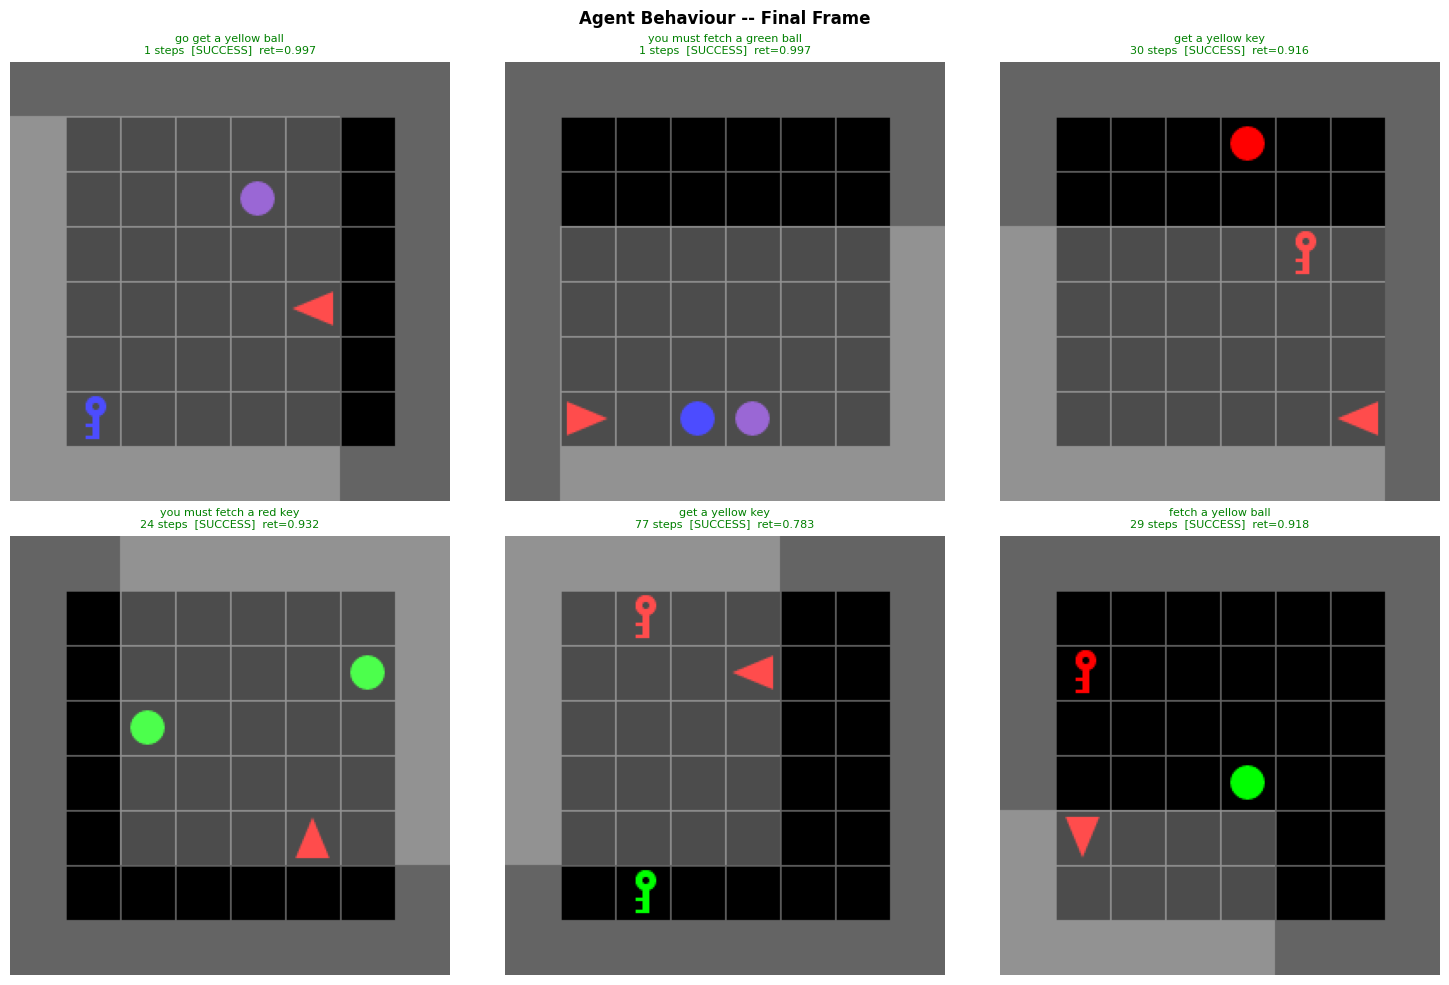

  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/gifs/ep01_ok.gif  (2 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/gifs/ep02_ok.gif  (2 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/gifs/ep03_ok.gif  (31 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/gifs/ep04_ok.gif  (25 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/gifs/ep05_ok.gif  (78 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_sparse_seed1_25-02-26-11-00-01/gifs/ep06_ok.gif  (30 frames)
  [film_dense] seed=  0  'go get a yellow ball'                 2 steps  [SUCCESS]
  [film_dense] seed=  7  'you must fetch a green ball'          4 steps  [SUCCESS]
  [film_dense] seed= 42  'get a yellow key'                     1 steps  [failed]
  [film_dense] seed= 77  'you must fetch a red key'            15 steps  [SUCCESS]
  [film_dense] seed=123  'get a yellow key'    

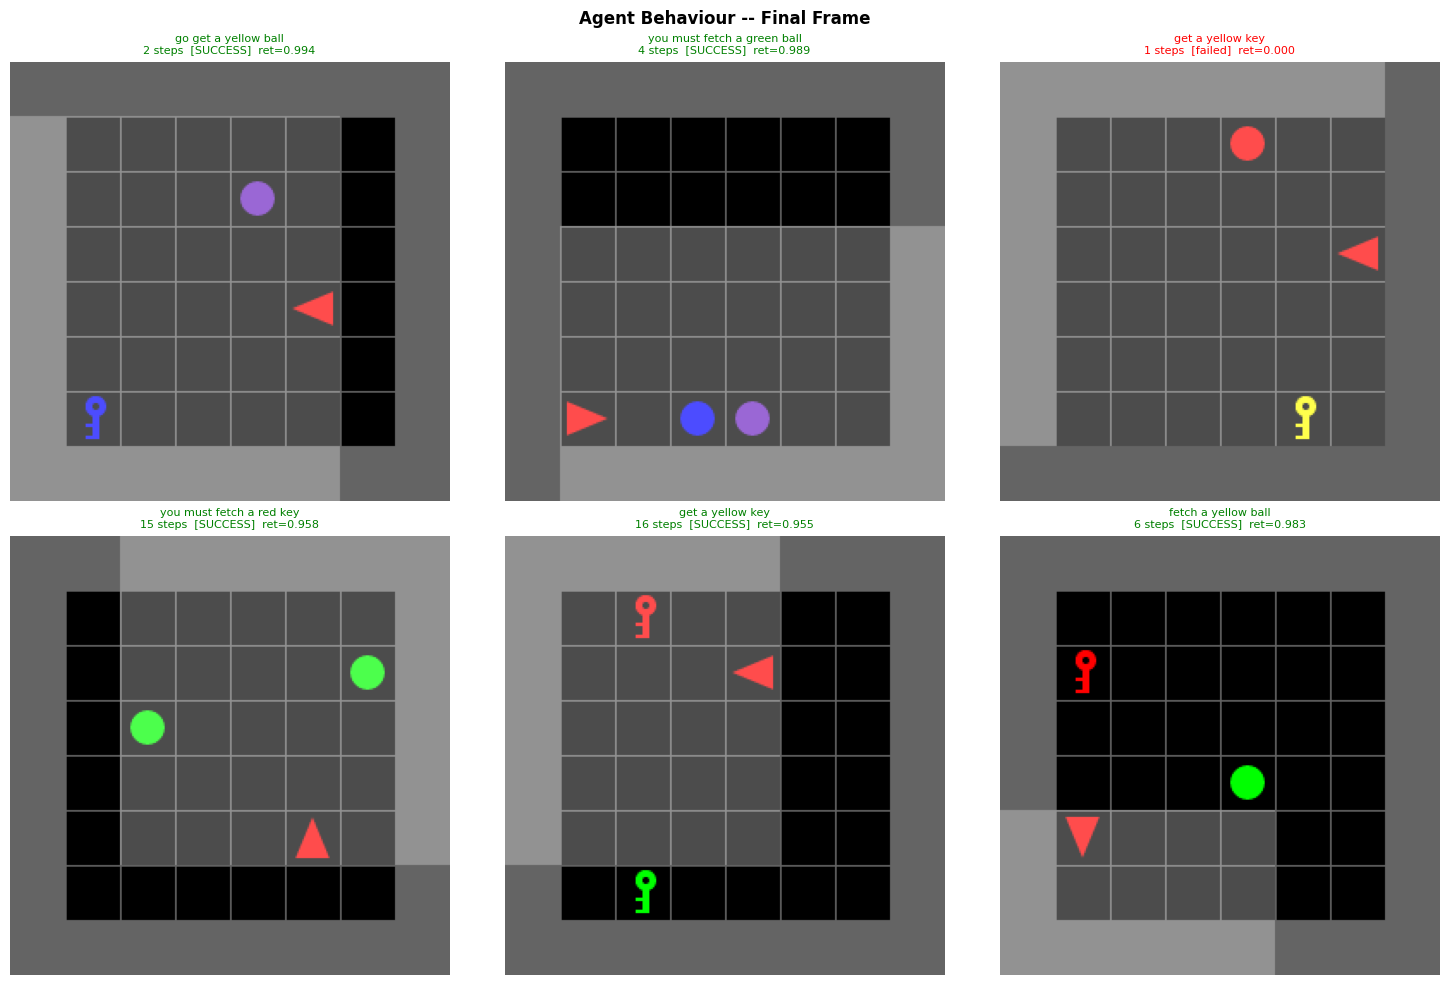

  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/gifs/ep01_ok.gif  (3 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/gifs/ep02_ok.gif  (5 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/gifs/ep03_fail.gif  (2 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/gifs/ep04_ok.gif  (16 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/gifs/ep05_ok.gif  (17 frames)
  Saved runs/MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13/gifs/ep06_ok.gif  (7 frames)


In [ ]:
RECORD_SEEDS = CFG['eval']['seeds']

print(f"Recording {len(RECORD_SEEDS)} episodes per variant...\n")

for name, info in run_results.items():
    model   = info['model']
    variant = info['variant']
    model.eval()

    episodes = []
    for seed in RECORD_SEEDS:
        # record_episode returns (frames, actions, success, mission, total_return)
        result = record_episode(
            model, preprocess_fn, env_id, DEVICE,
            seed=seed, dense_reward=False,
        )
        _, acts, success, mission, ret = result
        tag = 'SUCCESS' if success else 'failed'
        print(f"  [{name}] seed={seed:3d}  {mission!r:<35}  {len(acts):3d} steps  [{tag}]")
        episodes.append(result)

    sr = sum(e[2] for e in episodes)
    print(f"  success {sr}/{len(episodes)}\n")

    # Save a grid image showing the first frame of each recorded episode
    show_episode_grid(
        episodes,
        save_path=os.path.join(info['run_dir'], 'episode_grid.png'),
    )
    # Export each episode as an animated GIF for qualitative inspection
    save_gifs(
        episodes,
        gif_dir = os.path.join(info['run_dir'], 'gifs'),
        fps     = CFG['eval']['gif_fps'],
        resize  = CFG['eval']['gif_resize'],
    )

    info['episodes'] = episodes

## 8 · Inline animations

In [ ]:
# Render 2 inline HTML animations per variant for a quick visual comparison
for name, info in run_results.items():
    v = info['variant']
    print(f"\n{'─'*60}")
    print(f"  {v['label']}")
    print(f"{'─'*60}")
    show_animations(info['episodes'], n=2)


────────────────────────────────────────────────────────────
  Baseline
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a yellow ball'  3 steps  ret=0.992 --



-- Episode 2/2  [SUCCESS]  'you must fetch a green ball'  3 steps  ret=0.992 --



────────────────────────────────────────────────────────────
  Memory + text=ON
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a yellow ball'  1 steps  ret=0.997 --



-- Episode 2/2  [SUCCESS]  'you must fetch a green ball'  1 steps  ret=0.997 --



────────────────────────────────────────────────────────────
  FiLM  sparse reward
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a yellow ball'  1 steps  ret=0.997 --



-- Episode 2/2  [SUCCESS]  'you must fetch a green ball'  1 steps  ret=0.997 --



────────────────────────────────────────────────────────────
  FiLM  dense reward
────────────────────────────────────────────────────────────

-- Episode 1/2  [SUCCESS]  'go get a yellow ball'  2 steps  ret=0.994 --



-- Episode 2/2  [SUCCESS]  'you must fetch a green ball'  4 steps  ret=0.989 --


## Imitation learning

In [ ]:
import os, pickle
import numpy as np
import torch

@torch.no_grad()
def rollout_one_episode(env, model, preprocess_fn, device, deterministic=True):
    """Run a single episode and return the transition log and total return.

    Each step is stored as {"obs": obs, "action": action} for use as
    behavioural-cloning training data.  The @torch.no_grad() decorator keeps
    memory usage low during data collection.
    """
    obs, _ = env.reset()
    done, ep, ep_return = False, [], 0.0
    # Initialise the recurrent hidden state for memory-based models
    memory = torch.zeros(1, model.memory_size, device=device)

    while not done:
        ob        = preprocess_fn([obs], device=device)   # device kwarg places tensors on GPU
        dist, _, memory = model(ob, memory)
        # Deterministic mode picks the highest-probability action (greedy);
        # stochastic mode samples from the action distribution.
        action    = dist.probs.argmax(dim=1).item() if deterministic else dist.sample().item()
        ep.append({"obs": obs, "action": action})
        obs, reward, terminated, truncated, _ = env.step(action)
        done       = terminated or truncated
        ep_return += float(reward)

    return ep, ep_return


def collect_success_trajectories(
    make_env_fn, model, preprocess_fn, device,
    target_success_eps=200,
    max_episodes=5000,
    deterministic=True,
    success_threshold=0.09,    # sparse reward: 1-0.9*(s/S) ∈ [0.1,1] 
    save_path="success_trajs.pkl",
):
    """Collect successful episodes by rolling out the model and filtering by return.

    Episodes with return > success_threshold are kept as demonstrations.
    Progress is printed every 100 episodes.  Collection stops early once
    target_success_eps demonstrations have been gathered.
    The resulting list of episode dicts is pickled to save_path.
    """
    success_eps, all_returns = [], []

    for k in range(max_episodes):
        env = make_env_fn()
        ep, ep_ret = rollout_one_episode(env, model, preprocess_fn, device, deterministic)
        env.close()
        all_returns.append(ep_ret)

        if ep_ret > success_threshold:
            success_eps.append(ep)

        if (k + 1) % 100 == 0:
            sr = len(success_eps) / (k + 1)
            print(f"  episodes={k+1:4d}  collected={len(success_eps):3d}  "
                  f"success_rate={sr:.2%}  mean_ret={np.mean(all_returns[-100:]):.3f}")

        if len(success_eps) >= target_success_eps:
            break

    print(f"\nCollected {len(success_eps)} successful episodes out of {k+1} total")
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, "wb") as f:
        pickle.dump(success_eps, f)
    print(f"Saved -> {save_path}")
    return success_eps

In [ ]:
# Use sparse reward so success_threshold (> 0.09) is unambiguous
def make_env_fn():
    # Factory function that creates a fresh environment instance per episode,
    # avoiding shared state between collection runs.
    return make_env(env_id, dense_reward=False)

log_dir = r"runs"
# Path where the collected success trajectories will be pickled
traj_path = os.path.join(log_dir, "success_trajs.pkl")

# Point to the existing PPO run directory from which the teacher model is loaded
ckpt_dir = "runs\MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13\checkpoints"
# Path for the BC-initialised weights that will be saved after pretraining
bc_ckpt = os.path.join(ckpt_dir, "model_bc_init.pt")

In [ ]:
# Instantiate the film_dense model architecture to match the saved PPO checkpoint.
# use_memory and use_text must mirror the settings used during the original training run.
model = FilmACModel(
    obs_space, action_space,
    use_memory=True, use_text=True,
).to(DEVICE)

In [ ]:
# Load the final PPO checkpoint to use as the teacher policy for trajectory collection
ckpt_final = os.path.join(ckpt_dir, 'model_final.pt')
model.load_state_dict(torch.load(ckpt_final, map_location=DEVICE))
model.eval()

# Roll out the teacher policy and keep only the episodes where it succeeds,
# up to target_success_eps demonstrations or max_episodes attempts.
success_eps = collect_success_trajectories(
    make_env_fn = make_env_fn,
    model       = model,
    preprocess_fn = preprocess_fn,
    device      = DEVICE,
    target_success_eps = 200,
    max_episodes = 3000,
    deterministic = True,
    save_path = traj_path,
)

  episodes= 100  collected=  1  success_rate=1.00%  mean_ret=0.009
  episodes= 200  collected=  6  success_rate=3.00%  mean_ret=0.048
  episodes= 300  collected=  8  success_rate=2.67%  mean_ret=0.019
  episodes= 400  collected= 10  success_rate=2.50%  mean_ret=0.020
  episodes= 500  collected= 11  success_rate=2.20%  mean_ret=0.009
  episodes= 600  collected= 15  success_rate=2.50%  mean_ret=0.036
  episodes= 700  collected= 17  success_rate=2.43%  mean_ret=0.014
  episodes= 800  collected= 18  success_rate=2.25%  mean_ret=0.009
  episodes= 900  collected= 23  success_rate=2.56%  mean_ret=0.046
  episodes=1000  collected= 28  success_rate=2.80%  mean_ret=0.037
  episodes=1100  collected= 30  success_rate=2.73%  mean_ret=0.019
  episodes=1200  collected= 32  success_rate=2.67%  mean_ret=0.018
  episodes=1300  collected= 34  success_rate=2.62%  mean_ret=0.020
  episodes=1400  collected= 36  success_rate=2.57%  mean_ret=0.019
  episodes=1500  collected= 38  success_rate=2.53%  mean_ret=0

In [ ]:
import pickle
import torch
import torch.nn.functional as F

def bc_pretrain(
    model, preprocess_fn, device,
    traj_path,
    epochs=5,
    lr=1e-4,
    max_steps_per_ep=None,
):
    """Pretrain a model via Behavioural Cloning (BC) on saved demonstrations.

    For each (observation, action) pair in the demonstration episodes, the model
    is trained to maximise the log-probability of the expert action (cross-entropy
    loss).  Recurrent state is maintained across time steps within an episode but
    detached between steps to avoid backpropagation through time (BPTT).
    """
    with open(traj_path, "rb") as f:
        episodes = pickle.load(f)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()

    # Determine whether the model uses a recurrent memory module
    use_memory = (hasattr(model, "memory_size")
                  and model.memory_size is not None
                  and model.memory_size > 0)

    for epc in range(1, epochs + 1):
        total_loss, total_steps = 0.0, 0
        np.random.shuffle(episodes)

        for ep in episodes:
            # Reset hidden state at the start of each episode
            memory = torch.zeros(1, model.memory_size, device=device) if use_memory else None

            for t, step in enumerate(ep):
                if max_steps_per_ep is not None and t >= max_steps_per_ep:
                    break

                obs    = step["obs"]
                action = step["action"]

                # device kwarg places tensors on GPU
                ob = preprocess_fn([obs], device=device)

                if use_memory:
                    dist, _, new_memory = model(ob, memory)
                    # Detach to prevent gradients flowing across time steps (no BPTT)
                    memory = new_memory.detach()
                else:
                    dist, _, _ = model(ob, None)

                act  = torch.tensor([action], device=device, dtype=torch.long)
                # Negative log-likelihood loss: trains the policy to imitate the expert
                loss = -dist.log_prob(act).mean()

                # set_to_none=True is a minor optimisation over zeroing gradients
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

                total_loss  += float(loss.item())
                total_steps += 1

        print(f"[BC] epoch={epc}/{epochs}  "
              f"loss={total_loss / max(total_steps, 1):.4f}  "
              f"steps={total_steps}")

    return model

In [ ]:
# Reload the clean PPO weights before BC so the pretraining always starts
# from the same initialisation, independent of any previous cell runs.
model.load_state_dict(torch.load(ckpt_final, map_location=DEVICE))
model = bc_pretrain(
    model         = model,
    preprocess_fn = preprocess_fn,
    device        = DEVICE,
    traj_path     = traj_path,
    epochs        = 5,
    lr            = 1e-4,
)
# Persist the BC-initialised weights so the PPO fine-tuning cell can load them
torch.save(model.state_dict(), bc_ckpt)
print(f"Saved BC-initialized weights -> {bc_ckpt}")


[BC] epoch=1/5  loss=0.3949  steps=2964
[BC] epoch=2/5  loss=0.3250  steps=2964
[BC] epoch=3/5  loss=0.3013  steps=2964
[BC] epoch=4/5  loss=0.2799  steps=2964
[BC] epoch=5/5  loss=0.2689  steps=2964
Saved BC-initialized weights -> runs\MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13\checkpoints\model_bc_init.pt


In [ ]:
# ── BC -> PPO fine-tuning ──────────────────────────────────────────────────────
# Re-read config locals in case this cell is run independently
ppo       = CFG['ppo']
rew       = CFG['reward']
use_dense = rew.get('dense', True)
save_every = CFG['logging']['save_interval']

# Use an isolated run directory so BC+PPO results do not overwrite the PPO-only run
_ts_bc   = datetime.now().strftime('%d-%m-%y-%H-%M-%S')
bc_log_dir  = f"runs/{env_id}_bcppo_seed{SEED}_{_ts_bc}"
bc_ckpt_dir = os.path.join(bc_log_dir, "checkpoints")
bc_csv_path = os.path.join(bc_log_dir, "training_log.csv")
os.makedirs(bc_ckpt_dir, exist_ok=True)

# Load BC-initialized weights as the starting point for PPO fine-tuning
model.load_state_dict(torch.load(bc_ckpt, map_location=DEVICE))
model.train()
print(f"Loaded BC weights from {bc_ckpt}")
print(f"BC+PPO run dir: {bc_log_dir}\n")

# Recreate the PPO algorithm with a fresh optimizer so the BC learning rate
# state does not carry over into the RL fine-tuning phase.
algo = torch_ac.PPOAlgo(
    envs = [
        make_env(
            env_id,
            dense_reward           = use_dense,
            step_penalty           = rew['step_penalty'],
            first_sight_bonus      = rew['first_sight_bonus'],
            approach_scale         = rew['approach_scale'],
            success_reward         = rew['success_reward'],
            useless_action_penalty = rew['useless_action_penalty'],
        )
        for _ in range(CFG['env']['n_envs'])
    ],
    acmodel             = model,
    device              = DEVICE,
    num_frames_per_proc = ppo['rollout_steps'],
    discount            = ppo['gamma'],
    lr                  = ppo['lr'],
    gae_lambda          = ppo['gae_lambda'],
    entropy_coef        = ppo['ent_coef'],
    value_loss_coef     = ppo['value_coef'],
    max_grad_norm       = ppo['max_grad_norm'],
    recurrence          = ppo['recurrence'],
    preprocess_obss     = preprocess_fn,
    epochs              = ppo['train_epochs'],
    batch_size          = ppo['batch_size'],
    clip_eps            = ppo['clip_eps'],
)

# Write CSV header
with open(bc_csv_path, 'w', newline='') as f:
    csv.DictWriter(f, CSV_FIELDS).writeheader()

# Training loop (identical structure to §4)
num_frames = 0
update_idx = 0
t_last     = time.time()

while num_frames < ppo['frames_max']:
    # Collect a rollout across all parallel environments
    exps, logs = algo.collect_experiences()
    # Run PPO gradient updates on the collected rollout
    upd_logs   = algo.update_parameters(exps)
    num_frames += logs['num_frames']
    update_idx += 1

    # Build the CSV row; episode-level stats may be absent when no episode
    # completed during this rollout, so an empty string is stored instead.
    row = dict(
        update         = update_idx,
        global_step    = num_frames,
        mean_ep_return = (np.mean(logs['return_per_episode'])
                          if logs['return_per_episode'] else ''),
        mean_ep_len    = (np.mean(logs['num_frames_per_episode'])
                          if logs['num_frames_per_episode'] else ''),
        entropy     = upd_logs['entropy'],
        policy_loss = upd_logs['policy_loss'],
        value_loss  = upd_logs['value_loss'],
        grad_norm   = upd_logs['grad_norm'],
    )
    with open(bc_csv_path, 'a', newline='') as f:
        csv.DictWriter(f, CSV_FIELDS).writerow(row)

    # Periodically checkpoint the model weights
    if num_frames % save_every < logs['num_frames']:
        ckpt = os.path.join(bc_ckpt_dir, f'model_{num_frames}.pt')
        torch.save(model.state_dict(), ckpt)

    t_now    = time.time()
    duration = t_now - t_last
    fps      = logs['num_frames'] / max(duration, 1e-6)
    t_last   = t_now
    print(format_update_log(update_idx, num_frames, fps, duration, logs, upd_logs))

# Save the final BC+PPO model weights
bc_final = os.path.join(bc_ckpt_dir, 'model_final.pt')
torch.save(model.state_dict(), bc_final)
print(f"\nDone. Final checkpoint -> {bc_final}")

Loaded BC weights from runs\MiniGrid-Fetch-8x8-N3-v0_film_dense_seed1_25-02-26-11-39-13\checkpoints\model_bc_init.pt
BC+PPO run dir: runs/MiniGrid-Fetch-8x8-N3-v0_bcppo_seed1_25-02-26-23-04-22

U 1 | F 004096 | FPS 775 | D 5 | rR:μσmM 1.51 2.51 -0.62 11.65 | F:μσmM 21.47 26.67 3.00 168.00 | H 0.737 | V 6.212 | pL 1.665 | vL 4.978 | ∇ 2.715
U 2 | F 008192 | FPS 780 | D 5 | rR:μσmM 2.03 3.89 -2.35 12.16 | F:μσmM 80.23 114.39 1.00 320.00 | H 0.872 | V 5.844 | pL 1.625 | vL 4.817 | ∇ 4.827
U 3 | F 012288 | FPS 778 | D 5 | rR:μσmM 2.34 4.20 -2.40 12.14 | F:μσmM 78.31 109.31 1.00 320.00 | H 0.931 | V 5.561 | pL 1.470 | vL 4.452 | ∇ 5.314
U 4 | F 016384 | FPS 770 | D 5 | rR:μσmM 2.51 3.89 -2.28 12.58 | F:μσmM 58.53 84.21 1.00 320.00 | H 0.945 | V 4.818 | pL 1.279 | vL 4.171 | ∇ 3.934
U 5 | F 020480 | FPS 775 | D 5 | rR:μσmM 1.80 3.30 -1.73 11.14 | F:μσmM 61.34 93.94 2.00 320.00 | H 1.005 | V 4.572 | pL 1.254 | vL 3.096 | ∇ 3.376
U 6 | F 024576 | FPS 780 | D 5 | rR:μσmM 2.35 4.04 -2.76 12.85 |

Saved -> runs/MiniGrid-Fetch-8x8-N3-v0_bcppo_seed1_25-02-26-19-27-51\training_curves.png


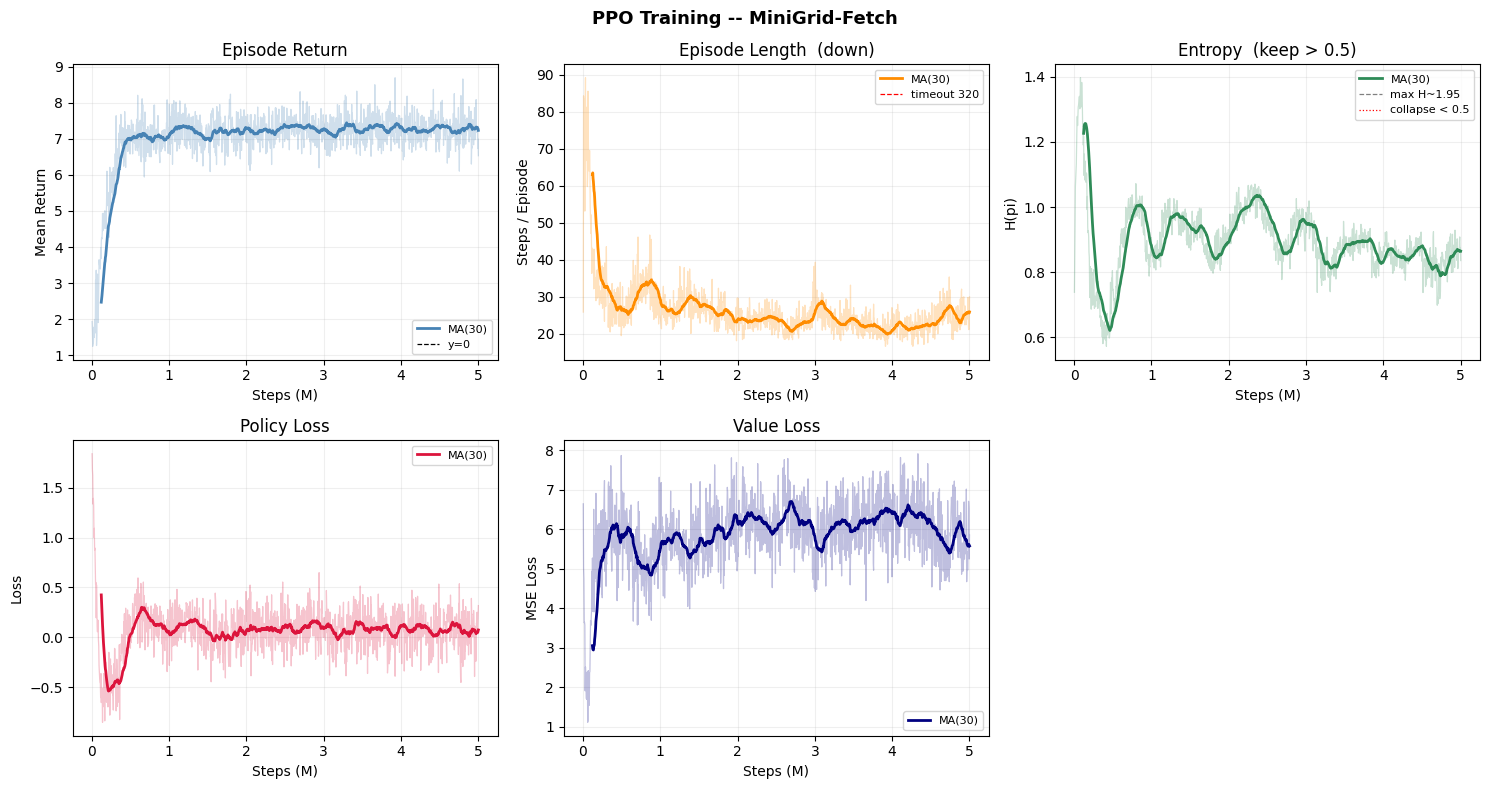


Final stats (last 50 updates):
  Return    : 7.2897
  Length    : 24.8576
  Entropy   : 0.8619
  PG Loss   : 0.0632


In [ ]:
# Plot the training curves for the BC+PPO run to compare against the PPO-only baselines
plot_training_curves(bc_csv_path, save_dir=bc_log_dir)

In [ ]:
# ── Evaluation ────────────────────────────────────────────────────────────────
# Switch to eval mode to disable dropout / batch-norm training behaviour
model.eval()

N_EVAL = CFG['eval']['n_episodes']
ep_rets, ep_lens, successes = [], [], []

for seed in range(N_EVAL):
    # record_episode runs one episode and returns
    # (frames, actions, success_flag, mission_string, total_return)
    _, acts, success, mission, ret = record_episode(
        model, preprocess_fn, env_id, DEVICE, seed=seed,
    )
    ep_rets.append(ret)
    ep_lens.append(len(acts))
    successes.append(int(success))

print(f"Evaluated {N_EVAL} episodes")
print(f"  Mean return  : {np.mean(ep_rets):.4f} +/- {np.std(ep_rets):.4f}")
print(f"  Mean length  : {np.mean(ep_lens):.1f}")
print(f"  Success rate : {np.mean(successes):.1%}")

Evaluated 50 episodes
  Mean return  : 0.5978 +/- 0.4431
  Mean length  : 29.0
  Success rate : 66.0%
